In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

RAW_PATH = "../data/raw/amazon-purchases-sample.csv"

df = pd.read_csv(RAW_PATH)

print("Shape:", df.shape)
df.head()


Shape: (1820, 8)


,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Category,Survey ResponseID
0,1/18/2018,17.16,1,PA,"NOW Foods, Certified Organic Better Stevia, Ex...",B005F9XFN0,SUGAR_SUBSTITUTE,GZ43D27
1,1/18/2018,FREE,1,PA,"F.M. Brown'S Encore Parakeet Food, 5-Pound",B000HHSHZG,PET_FOOD,RN79L07
2,1/18/2018,FREE,1,PA,COTTON CRAFT - Scandia Stripe 12 Pack - Pure C...,B014V1IYEM,TOWEL,KN18K36
3,1/18/2018,12.99,1,PA,"XREXS 4 Channels Digital Kitchen Timer Clock, ...",B01K4JKFK6,TIMER,JS10H76
4,1/18/2018,$12.87,1,pa,Premium Wrist Rests for Keyboard and Mouse Pad...,B01A92ETXM,WRIST_REST,EA67M16


Schema & Type Issues (Before Cleaning)

In [3]:
df.dtypes

Order Date                  object
Purchase Price Per Unit     object
Quantity                     int64
Shipping Address State      object
Title                       object
ASIN/ISBN (Product Code)    object
Category                    object
Survey ResponseID           object
dtype: object

In [4]:
object_cols = df.select_dtypes(include=["object", "string"]).columns

schema_issues_found = False

for col in object_cols:
    converted = pd.to_numeric(df[col], errors="coerce")
    success_rate = converted.notna().mean()
    
    if success_rate > 0.9:
        print(f"Column '{col}' → {round(success_rate*100,2)}% numeric-like but stored as text")
        schema_issues_found = True

if not schema_issues_found:
    print(" No columns detected that are numeric-like but stored as object/string.")

 No columns detected that are numeric-like but stored as object/string.


Missing Value Analysis

In [5]:
missing_percent = df.isna().mean() * 100
missing_percent.sort_values(ascending=False)

Category                    3.681319
Title                       3.681319
Shipping Address State      3.351648
Order Date                  0.000000
Quantity                    0.000000
Purchase Price Per Unit     0.000000
ASIN/ISBN (Product Code)    0.000000
Survey ResponseID           0.000000
dtype: float64

Duplicate Detection (Before Cleaning)

In [6]:
duplicate_count = df.duplicated().sum()
print("Exact duplicates of earlier rows across all columns.:", duplicate_count)

Exact duplicates of earlier rows across all columns.: 4


In [7]:
subset_cols = [
    "Order Date",
    "ASIN/ISBN (Product Code)",
    "Purchase Price Per Unit",
    "Quantity"
]

logical_dups = df.duplicated(subset=subset_cols).sum()

print("Logical duplicates based on transaction definition:", logical_dups)


Logical duplicates based on transaction definition: 7


In [8]:
df["Survey ResponseID"].nunique(), len(df)
df["Survey ResponseID"].value_counts()

Survey ResponseID
CQ87B91    2
CT18J65    2
GS69D31    2
NT99L02    2
NB42N86    1
          ..
MM00A58    1
YP73J91    1
NY00Y68    1
RL57P53    1
NO13A22    1
Name: count, Length: 1816, dtype: int64

Outlier Detection (Before Cleaning)

In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns
numeric_cols

Index(['Quantity'], dtype='object')

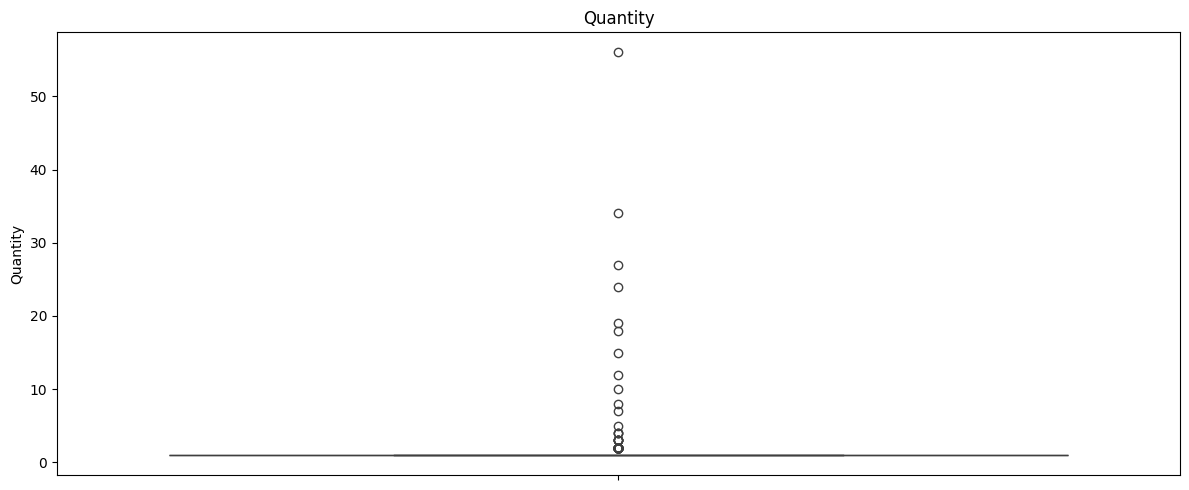

In [10]:
plt.figure(figsize=(12,5))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [11]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    print(f"{col} → {outliers} potential outliers")

Quantity → 103 potential outliers


Business Rule Checks (Before Cleaning)

In [12]:
if "Quantity" in df.columns:
    print("Quantity <= 0 violations:", (df["Quantity"] <= 0).sum())

if "Price" in df.columns:
    print("Price <= 0 violations:", (df["Price"] <= 0).sum())


Quantity <= 0 violations: 0


Categorical Inconsistency Check

In [ ]:
for col in df.select_dtypes(include="object").columns:
    unique_vals = df[col].dropna().unique()
    
    if len(unique_vals) < 20:  # manageable category size
        print(f"\nColumn: {col}")
        print(unique_vals[:10])



Column: Shipping Address State
<StringArray>
['PA', 'VT', 'VA', 'SD', 'CA', 'MN', 'ID', 'NE', 'WY']
Length: 9, dtype: str

Column: Survey ResponseID
<StringArray>
['R_037XK72IZBJyF69', 'R_03aEbghUILs9NxD', 'R_06RZP9pS7kONINr']
Length: 3, dtype: str


C:\Users\Neha KB\AppData\Local\Temp\ipykernel_19808\929369620.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [ ]:
for col in df.select_dtypes(include="object").columns:
    if df[col].astype(str).str.contains("  ").any():
        print(f"{col} contains extra whitespace")


Title contains extra whitespace


C:\Users\Neha KB\AppData\Local\Temp\ipykernel_19808\1607450581.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


Summarize Issues Found

In [ ]:
print("=== DATA QUALITY SUMMARY (RAW) ===")

print("\nMissing Values:")
print(missing_percent[missing_percent > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nPotential Outliers:")
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f"{col}: {outliers}")


=== DATA QUALITY SUMMARY (RAW) ===

Missing Values:
Shipping Address State    1.211454
Title                     3.689427
Category                  3.689427
dtype: float64

Duplicate Rows: 4

Potential Outliers:
Purchase Price Per Unit: 121
Quantity: 102
